In [ ]:
from torch import nn
from torch import optim
from torch.nn import functional as F
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import FashionMNIST
from matplotlib import pyplot as plt
from torchvision import transforms
from tqdm.auto import tqdm
from model_functions import get_model_results
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
import requests
from pathlib import Path
if Path("helper_functions.py").is_file():
    print("ol skipin dih not gonna do it n shi")
else:
    print("ol downloading sih gonna download it n shi")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f:
        f.write(request.content)
from helper_functions import accuracy_fn

ol skipin dih not gonna do it n shi


In [ ]:
device

'cuda'

In [ ]:
train_data = FashionMNIST(root='data',
                         download=True,
                         train=True,
                         transform=transforms.ToTensor())
test_data = FashionMNIST(root="data",
                         download=True,
                         train=False,
                         transform=transforms.ToTensor())

In [ ]:
classes = train_data.classes
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

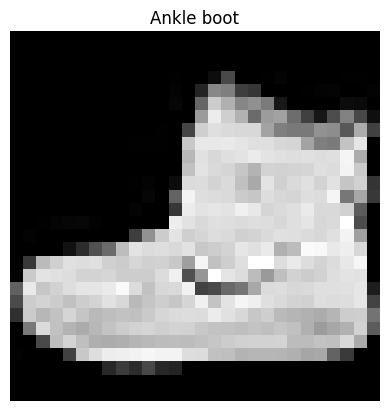

In [ ]:
image, label = train_data[0]
plt.title(classes[label])
plt.axis("off")
plt.imshow(image.squeeze(), cmap="gray")

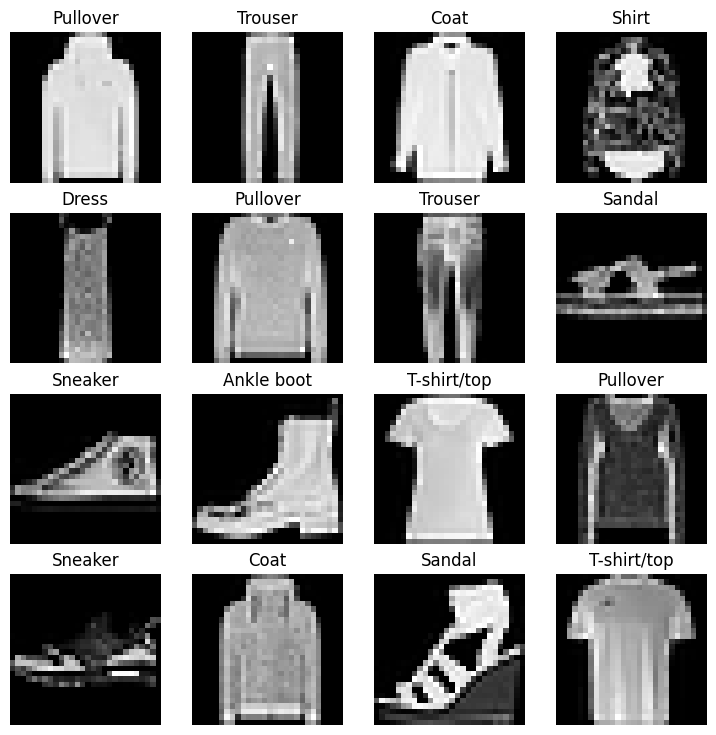

In [ ]:

fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows*cols+1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, lbl = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(classes[lbl])
    plt.axis("off")

In [ ]:
train_dataloader = DataLoader(train_data,
                              shuffle=True,
                              batch_size=32,
                              num_workers=10)
test_dataloader = DataLoader(test_data,
                             shuffle=False,
                             batch_size=32,
                             num_workers=6)

In [ ]:
f"length of train loader {len(train_dataloader)}, length of test loader {len(test_dataloader)}"

'length of train loader 1875, length of test loader 313'

In [ ]:
features, labels = next(iter(train_dataloader))

In [ ]:
rand_idx = torch.randint(0, len(features), size=[1]).item()

In [ ]:
img, lbl = features[rand_idx], classes[labels[rand_idx]]

Text(0.5, 1.0, 'Shirt')

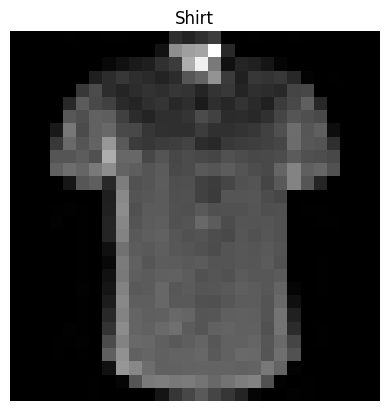

In [ ]:
plt.imshow(img.squeeze(), cmap="gray")
plt.axis(False)
plt.title(lbl)

In [ ]:
class FashionModel(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()
        self.stack = nn.Sequential(nn.Flatten(),
                                   nn.Linear(in_features=input_shape, out_features=hidden_units),
                                   nn.ReLU(),
                                   nn.Linear(in_features=hidden_units, out_features=output_shape),
                                   nn.ReLU())
    def forward(self, x):
        return self.stack(x)
model = FashionModel(28*28, 10, 10).to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(params=model.parameters(), lr=1e-3)

In [ ]:
model_results = get_model_results(model, test_dataloader, criterion, device)
model_results

{'Loss: ': 2.305656909942627,
 'accuracy': 10.333466453674122,
 'model': 'FashionModel'}

In [ ]:
def training_epoch(model, device, dataloader, optimizer, criterion):
    train_loss = 0
    for batch, (x, y) in enumerate(dataloader):
        x, y = x.to(device), y.to(device)
        model.train()
        pred = model(x)
        loss = criterion(pred, y)
        train_loss += loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch % 400 == 0:
            print(f"we at batch: {batch * len(x)}/{len(train_dataloader.dataset)}")
    train_loss /= len(train_dataloader)
    return train_loss


def testing_epoch(model, device, dataloader, criterion, accuracy_fn):
    test_loss = 0
    test_acc = 0
    model.eval()
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            test_loss += criterion(pred, y)
            test_acc += accuracy_fn(y_true=y, y_pred=pred.argmax(dim=1))
        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)
    print(f"\ntest_loss: {test_loss:.4f}, test_acc: {test_acc:.4}")
    return test_loss, test_acc

In [ ]:
class CNNfashion(nn.Module):
    def __init__(self, input_shape, hid_units, output_shape):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hid_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=hid_units,
                      out_channels=hid_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(hid_units, hid_units, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hid_units*49,
                      hid_units),
            nn.Linear(hid_units,
                      output_shape)
        )
    def forward(self, x):
        x = self.conv_block(x)
        #print(x.shape)
        x = self.conv_block2(x)
        #print(x.shape)
        x = self.fc(x)
        return x
model2 = CNNfashion(1, 10, 10).to(device)

In [ ]:
optimizer = optim.SGD(params=model2.parameters(), lr=1e-1)

In [ ]:
for epoch in tqdm(range(7)):
    print(f"epoch: {epoch}")
    training_epoch(model2,
                   device,
                   train_dataloader,
                   optimizer,
                   criterion)
    testing_epoch(model2,
                  device,
                  test_dataloader,
                  criterion,
                  accuracy_fn)

  0%|          | 0/7 [00:00<?, ?it/s]

epoch: 0
we at batch: 0/60000
we at batch: 12800/60000
we at batch: 25600/60000
we at batch: 38400/60000
we at batch: 51200/60000

test_loss: 0.3611, test_acc: 86.53
epoch: 1
we at batch: 0/60000
we at batch: 12800/60000
we at batch: 25600/60000
we at batch: 38400/60000
we at batch: 51200/60000

test_loss: 0.3683, test_acc: 86.77
epoch: 2
we at batch: 0/60000
we at batch: 12800/60000
we at batch: 25600/60000
we at batch: 38400/60000
we at batch: 51200/60000

test_loss: 0.3063, test_acc: 88.54
epoch: 3
we at batch: 0/60000
we at batch: 12800/60000
we at batch: 25600/60000
we at batch: 38400/60000
we at batch: 51200/60000

test_loss: 0.3055, test_acc: 88.79
epoch: 4
we at batch: 0/60000
we at batch: 12800/60000
we at batch: 25600/60000
we at batch: 38400/60000
we at batch: 51200/60000

test_loss: 0.3111, test_acc: 88.58
epoch: 5
we at batch: 0/60000
we at batch: 12800/60000
we at batch: 25600/60000
we at batch: 38400/60000
we at batch: 51200/60000

test_loss: 0.3071, test_acc: 88.79
epoc

In [ ]:
get_model_results(model2, test_dataloader, criterion, device)

{'Loss: ': 0.3014727532863617,
 'accuracy': 88.89776357827476,
 'model': 'CNNfashion'}

In [ ]:
import pandas as pd
results = pd.DataFrame([get_model_results(model2, test_dataloader, criterion, device),
                        get_model_results(model, test_dataloader, criterion, device)])

In [ ]:
results

,Loss:,accuracy,model
0,0.301473,88.897764,CNNfashion
1,2.305657,10.333466,FashionModel


In [ ]:
# Function to make a prediction on a single image
def predict_single_image(model, image_tensor, device):
    # 1. Ensure the model is in evaluation mode
    model.eval()
    
    # 2. Add a batch dimension and move to the device (GPU)
    # The model expects [Batch, Channel, Height, Width]. 
    # Our image_tensor is currently [1, 28, 28]. We need to add the batch dim.
    input_tensor = image_tensor.unsqueeze(0).to(device)
    
    # 3. Disable gradient tracking
    with torch.no_grad():
        # 4. Forward Pass: Get the logits
        output_logits = model(input_tensor)
    
    # 5. Convert logits to class index
    # argmax(dim=1) gets the highest score's index, which is the predicted digit
    output_logits = output_logits.squeeze()
    predicted_class = output_logits.argmax(dim=0).item()
    
    return predicted_class

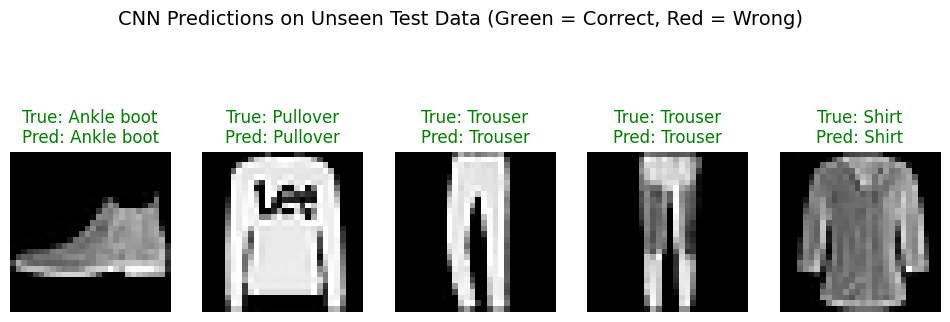

In [ ]:
# Grab the first 5 samples from the raw test dataset
test_samples = []
for i in range(5):
    # Get the raw tensor and true label from the dataset
    image_tensor, true_label = test_data[i]
    
    # Get the model's prediction
    predicted_label = predict_single_image(model2, image_tensor, device)
    
    # Denormalize the image for display (if you used simple transform, 
    # it's already 0-1 and this is fine)
    image_display = image_tensor.squeeze()
    
    test_samples.append({
        'image': image_display, 
        'true': true_label, 
        'predicted': predicted_label
    })

# Plotting the results
plt.figure(figsize=(12, 4))
for i, sample in enumerate(test_samples):
    ax = plt.subplot(1, 5, i + 1)
    
    plt.imshow(sample['image'], cmap="gray")
    
    color = 'green' if sample['predicted'] == sample['true'] else 'red'
    title = f"True: {classes[sample['true']]}\nPred: {classes[sample['predicted']]}"
    
    plt.title(title, color=color)
    plt.axis("off")

plt.suptitle(
    "CNN Predictions on Unseen Test Data (Green = Correct, Red = Wrong)", 
    y=1.05, 
    fontsize=14
)
plt.show()

In [ ]:
import torchmetrics
from mlxtend.plotting import plot_confusion_matrix

In [ ]:
preds = []
model2.eval()
with torch.no_grad():
    for x, y in tqdm(test_dataloader, desc="Makin em preds for papa"):
        x, y = x.to(device), y.to(device)
        lgt = model2(x)
        pred = lgt.argmax(dim=1)
        preds.append(pred.cpu())
pred_tnsr = torch.cat(preds)
pred_tnsr[:10]

Makin em preds for papa:   0%|          | 0/313 [00:00<?, ?it/s]

tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [ ]:
confmat = torchmetrics.classification.MulticlassConfusionMatrix(num_classes=10)
tnsr = confmat(preds=pred_tnsr,
               target=test_data.targets)

In [ ]:
tnsr

tensor([[797,   0,   7,  30,   4,   1, 149,   0,  12,   0],
        [  0, 987,   0,   7,   3,   0,   1,   0,   2,   0],
        [ 14,   2, 829,   7,  33,   1, 113,   0,   1,   0],
        [ 19,  11,  10, 879,  30,   0,  49,   0,   2,   0],
        [  1,   0, 118,  26, 716,   0, 135,   0,   4,   0],
        [  0,   0,   0,   0,   0, 982,   0,  10,   1,   7],
        [ 75,   4,  44,  27,  53,   0, 784,   0,  13,   0],
        [  0,   0,   0,   0,   0,  16,   0, 953,   1,  30],
        [  0,   0,   0,   2,   2,   3,   2,   1, 990,   0],
        [  0,   0,   0,   0,   0,   5,   1,  21,   0, 973]])

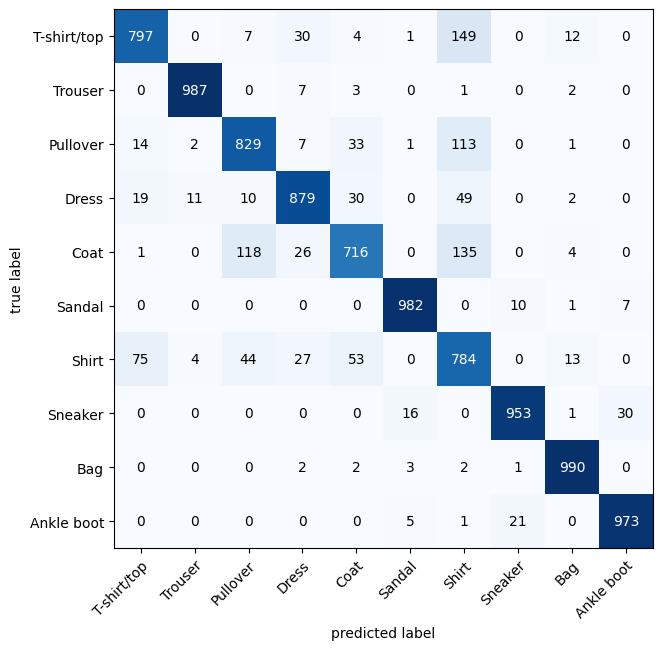

In [ ]:
fig, ax = plot_confusion_matrix(
    conf_mat=tnsr.numpy(),
    class_names=classes,
    figsize=(10, 7)
)

In [ ]:
torch.save(model2.state_dict(), "models/fashionCNN.pth")